<a href="https://colab.research.google.com/github/useanynoms-commits/IDRA/blob/main/Assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Executive Hotel Booking EDA - Complete Analysis
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('Day15_Executive_Hotel_Booking_EDA_Dataset.csv')

In [2]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nInfo:")
df.info()
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (25180, 35)

First 5 rows:
  Booking_ID  Hotel_Type Hotel_Location Booking_Date Arrival_Date  \
0  HTL024548  City Hotel         London   2024-07-29   2025-07-04   
1  HTL019878  City Hotel         London   2024-05-28   2025-02-08   
2  HTL017377  City Hotel         Lisbon   2024-05-10   2024-06-20   
3  HTL003352  City Hotel         Lisbon   2024-03-15   2024-04-07   
4  HTL012521  City Hotel         London   2024-08-21   2025-05-30   

   Lead_Time_Days  Weekend_Nights  Weekday_Nights  Adults  Children  ...  \
0             340               2               2       2       0.0  ...   
1             256               1               2       2       2.0  ...   
2              41               1               1       4       0.0  ...   
3              23               0               2       2       0.0  ...   
4             282               0               3       4       0.0  ...   

   Meal_Type Total_Nights     ADR Required_Car_Parking_Spaces  \
0         HB            4  17

In [5]:
# Remove duplicates
df = df.drop_duplicates()
print(df.shape)

(25000, 35)


In [6]:
# Handle missing values
df['Hotel_Location'] = df['Hotel_Location'].fillna('Unknown')
df['Children'] = df['Children'].fillna(0)
df['Country'] = df['Country'].fillna('GBR')
df['Agent_ID'] = df['Agent_ID'].fillna(0)
df['Company_ID'] = df['Company_ID'].fillna(0)
df['Meal_Type'] = df['Meal_Type'].fillna('HB')
df['ADR'] = df['ADR'].fillna(df['ADR'].median())
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())

In [7]:
# Convert dates
df['Booking_Date'] = pd.to_datetime(df['Booking_Date'])
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'])

In [8]:
# Standardize categorical values
df['Hotel_Type'] = df['Hotel_Type'].str.title()
df['Hotel_Location'] = df['Hotel_Location'].str.title()
df['Market_Segment'] = df['Market_Segment'].str.title()
df['Distribution_Channel'] = df['Distribution_Channel'].str.title()
df['Customer_Type'] = df['Customer_Type'].str.title()
df['Meal_Type'] = df['Meal_Type'].str.title()
df['Deposit_Type'] = df['Deposit_Type'].str.title()

In [9]:
# Derived metrics
df['Room_Changed'] = (df['Room_Type_Reserved'] != df['Room_Type_Assigned']).astype(int)
df['Total_Nights'] = df['Weekend_Nights'] + df['Weekday_Nights']

print(f"Dataset Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")

Dataset Shape: (25000, 36)
Missing Values: 0


DESCRIPTIVE STATISTICS

In [10]:
# Numerical columns summary
num_cols = ['Lead_Time_Days', 'ADR', 'Total_Nights', 'Total_Special_Requests',
            'Satisfaction_Score', 'Estimated_Revenue', 'Adults', 'Children', 'Babies']
print("\nNumerical Variables Summary:")
print(df[num_cols].describe().round(2))


Numerical Variables Summary:
       Lead_Time_Days       ADR  Total_Nights  Total_Special_Requests  \
count        25000.00  25000.00      25000.00                25000.00   
mean           182.22    140.59          3.69                    1.10   
std            105.63     47.73          2.07                    1.05   
min              0.00     30.80          1.00                    0.00   
25%             91.00    105.70          2.00                    0.00   
50%            182.00    134.40          4.00                    1.00   
75%            273.00    168.96          5.00                    2.00   
max            920.00    710.50         13.00                    5.00   

       Satisfaction_Score  Estimated_Revenue    Adults  Children    Babies  
count            25000.00           25000.00  25000.00  25000.00  25000.00  
mean                 3.85             535.37      2.20      0.37      0.04  
std                  0.40             389.64      0.66      0.66      0.23  
min 

In [11]:
# Categorical columns summary
cat_cols = ['Hotel_Type', 'Market_Segment', 'Deposit_Type', 'Customer_Type',
            'Meal_Type', 'Is_Canceled', 'Is_Repeated_Guest']
print("\nCategorical Variables Summary:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head())


Categorical Variables Summary:

Hotel_Type:
Hotel_Type
City Hotel      15611
Resort Hotel     9389
Name: count, dtype: int64

Market_Segment:
Market_Segment
Online Ta        10804
Offline Ta/To     5440
Direct            3808
Corporate         2990
Groups            1910
Name: count, dtype: int64

Deposit_Type:
Deposit_Type
Non Refund    12401
No Deposit    12144
Refundable      455
Name: count, dtype: int64

Customer_Type:
Customer_Type
Contract           6403
Transient-Party    6287
Group              6283
Transient          6027
Name: count, dtype: int64

Meal_Type:
Meal_Type
Hb           5132
Bb           5034
Undefined    4943
Fb           4910
Sc           4906
Name: count, dtype: int64

Is_Canceled:
Is_Canceled
1    18044
0     6956
Name: count, dtype: int64

Is_Repeated_Guest:
Is_Repeated_Guest
0    20678
1     4322
Name: count, dtype: int64


UNIVARIATE ANALYSIS

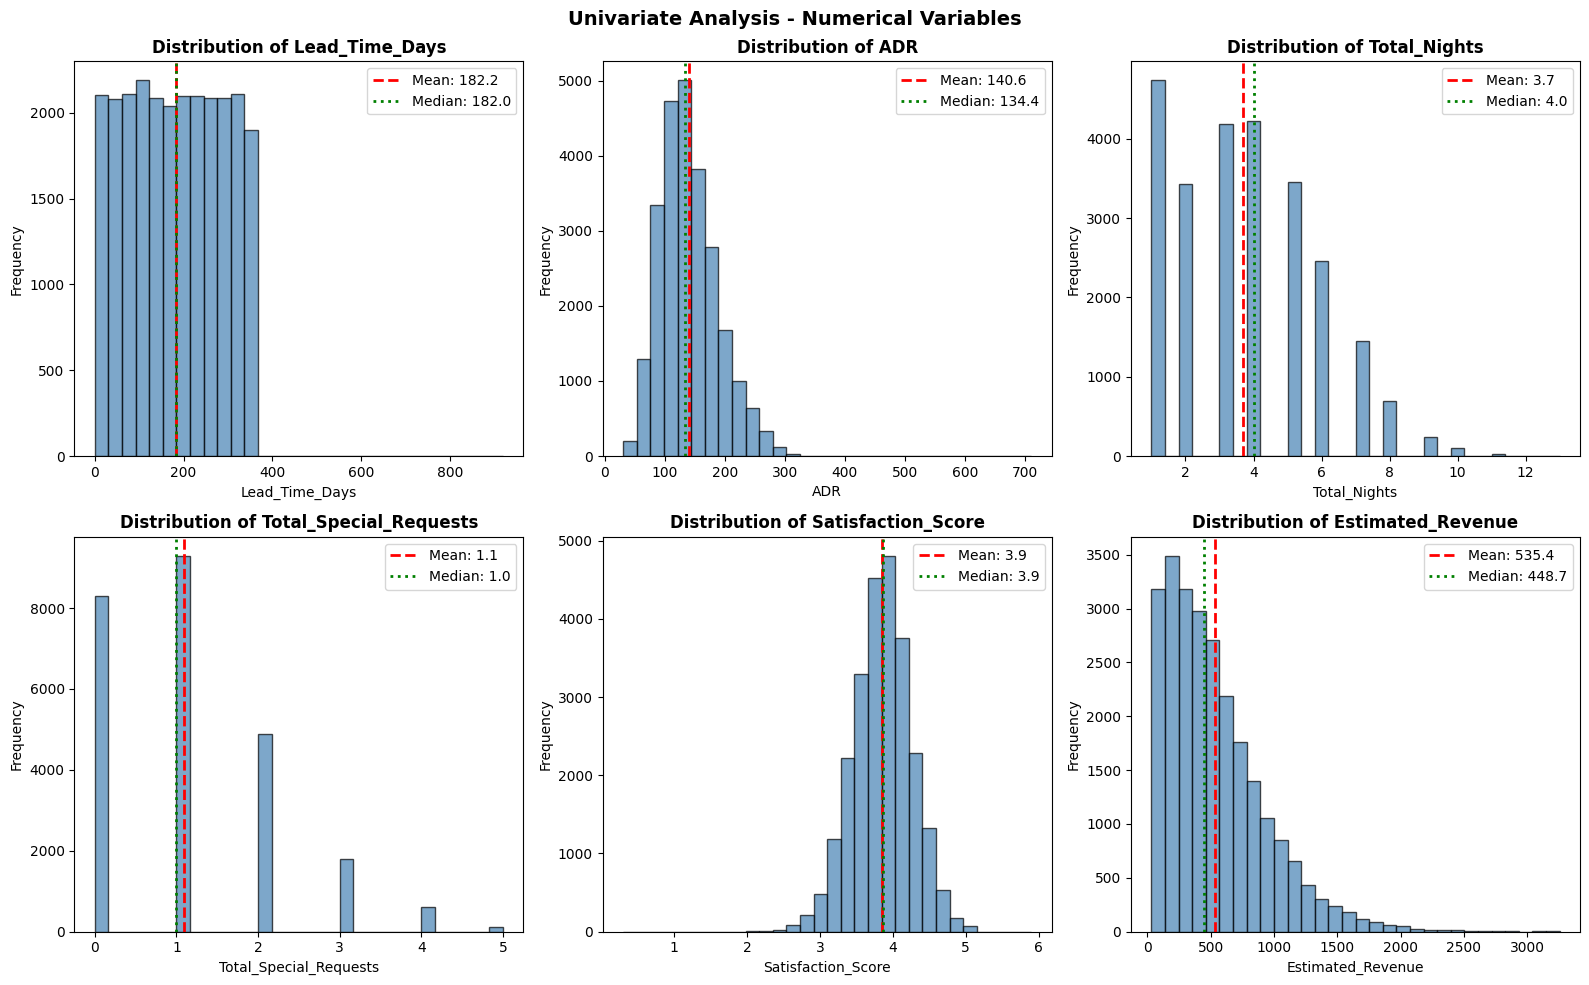

In [12]:
# Distribution plots for numerical variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
num_cols_plot = ['Lead_Time_Days', 'ADR', 'Total_Nights', 'Total_Special_Requests', 'Satisfaction_Score', 'Estimated_Revenue']

for i, col in enumerate(num_cols_plot):
    r, c = i // 3, i % 3
    axes[r, c].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[r, c].axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2,
                       label=f'Mean: {df[col].mean():.1f}')
    axes[r, c].axvline(df[col].median(), color='green', linestyle='dotted', linewidth=2,
                       label=f'Median: {df[col].median():.1f}')
    axes[r, c].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[r, c].set_xlabel(col)
    axes[r, c].set_ylabel('Frequency')
    axes[r, c].legend()
plt.suptitle('Univariate Analysis - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

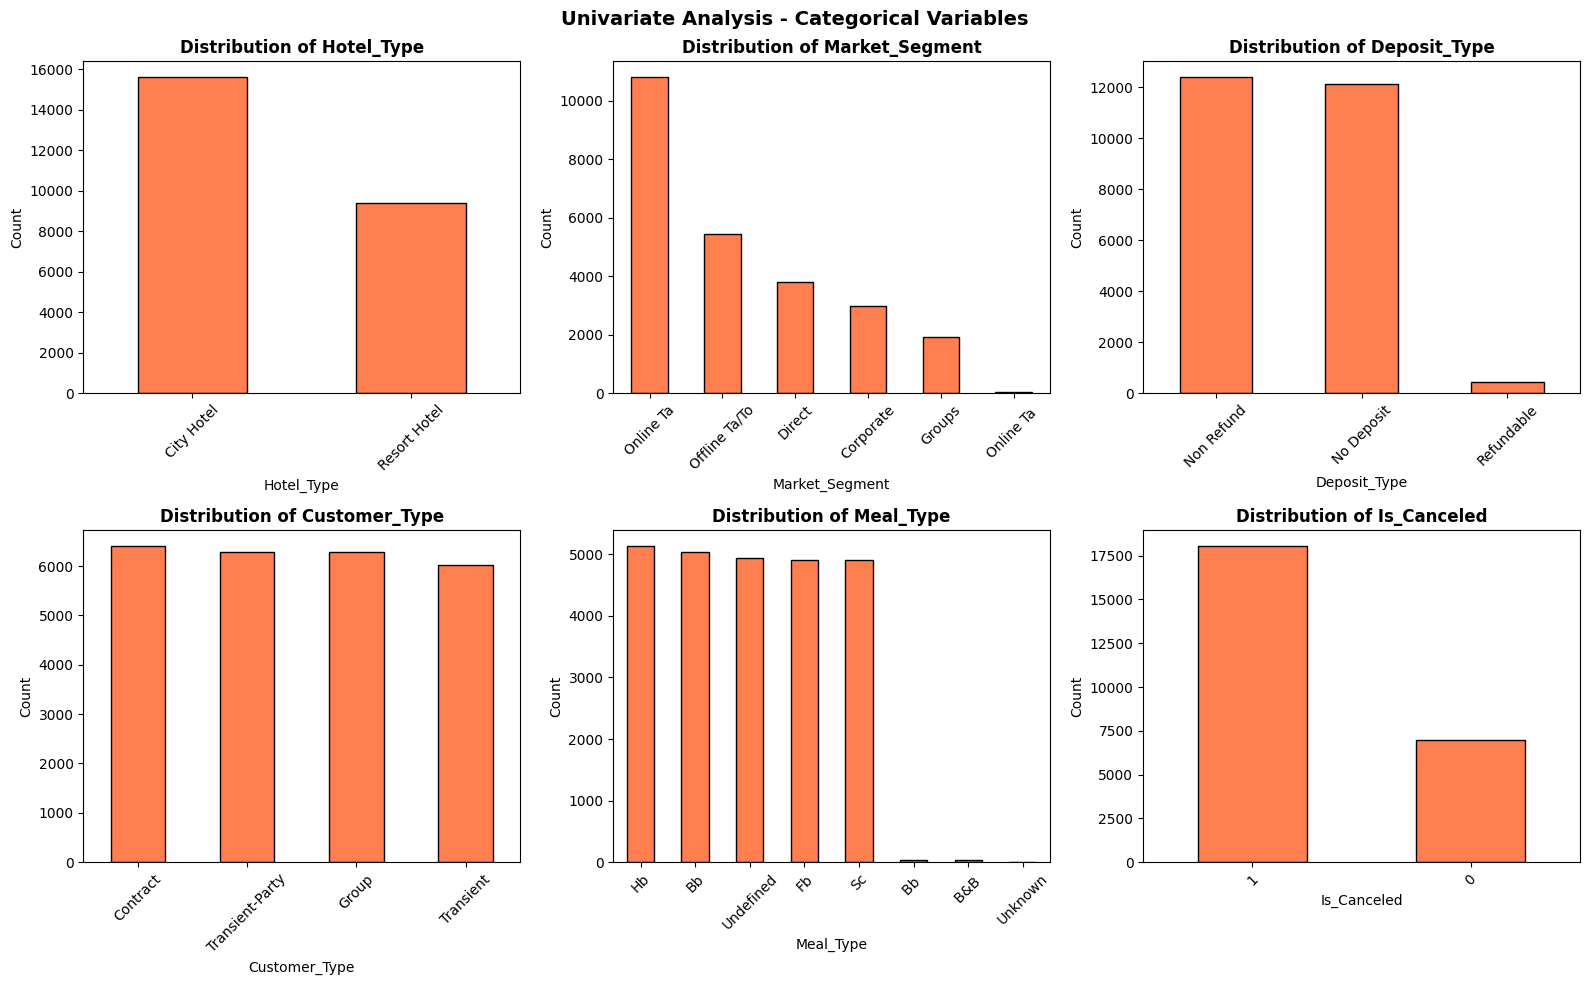

In [13]:
# Categorical variables - count plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cat_plot = ['Hotel_Type', 'Market_Segment', 'Deposit_Type', 'Customer_Type', 'Meal_Type', 'Is_Canceled']

for i, col in enumerate(cat_plot):
    r, c = i // 3, i % 3
    df[col].value_counts().plot(kind='bar', ax=axes[r, c], color='coral', edgecolor='black')
    axes[r, c].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[r, c].set_xlabel(col)
    axes[r, c].set_ylabel('Count')
    axes[r, c].tick_params(axis='x', rotation=45)
plt.suptitle('Univariate Analysis - Categorical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

BIVARIATE ANALYSIS

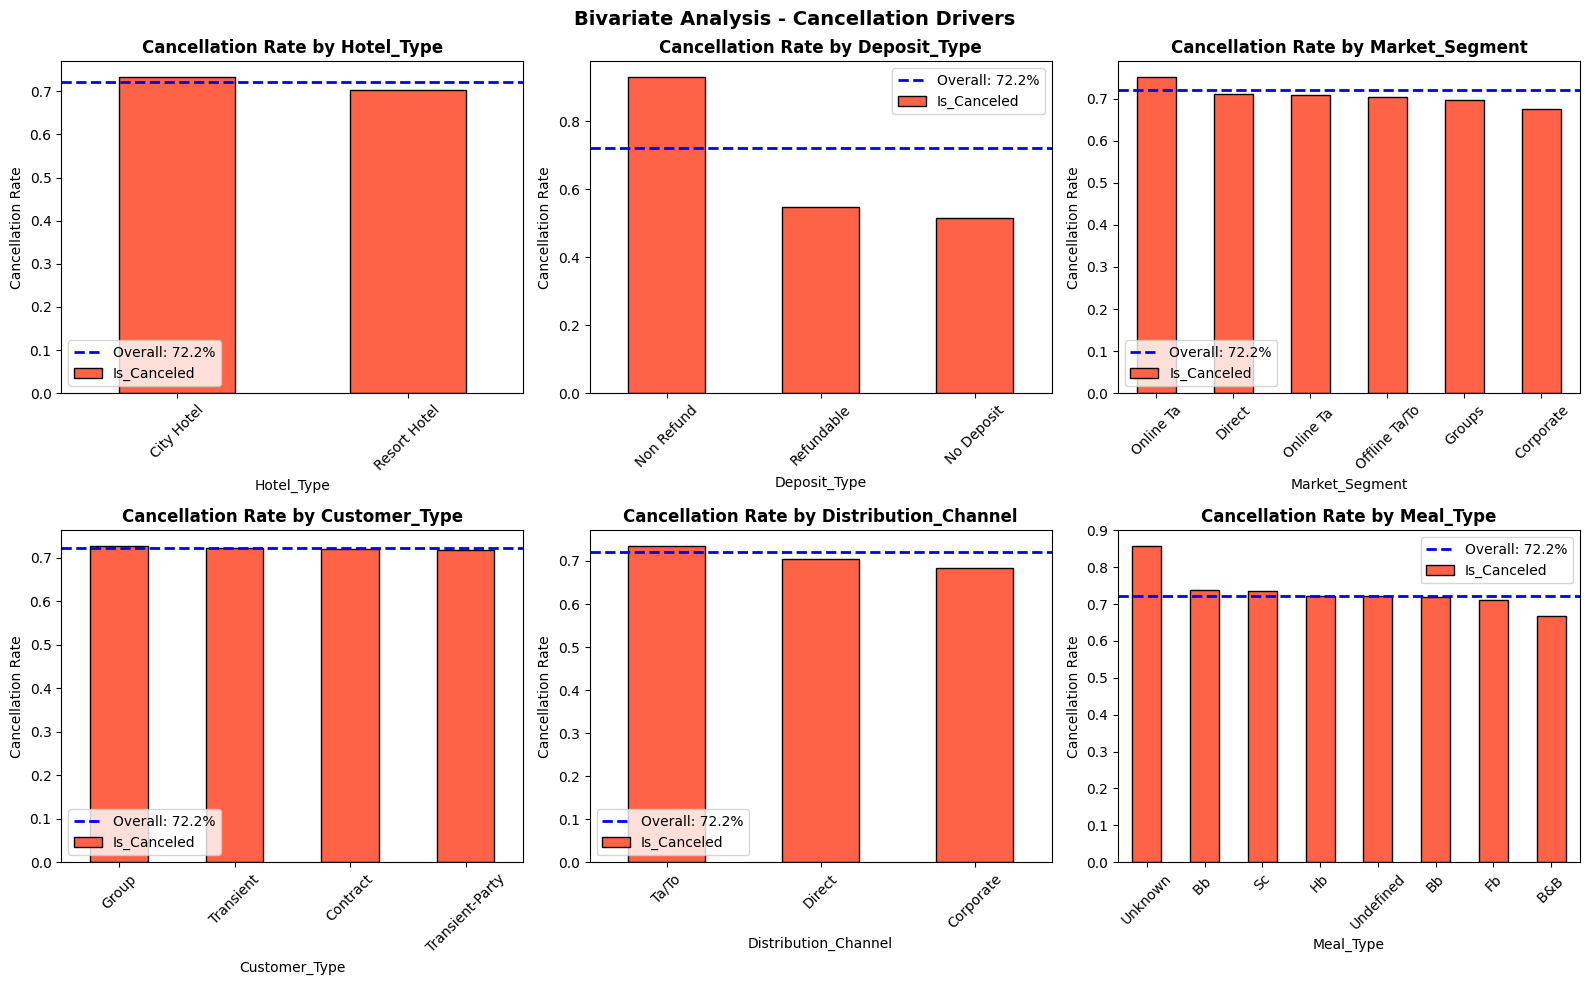

In [14]:
# Cancellation Rate by Key Factors
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
factors = ['Hotel_Type', 'Deposit_Type', 'Market_Segment', 'Customer_Type', 'Distribution_Channel', 'Meal_Type']

for i, factor in enumerate(factors):
    r, c = i // 3, i % 3
    cancel_rate = df.groupby(factor)['Is_Canceled'].mean().sort_values(ascending=False)
    cancel_rate.plot(kind='bar', ax=axes[r, c], color='tomato', edgecolor='black')
    axes[r, c].axhline(y=df['Is_Canceled'].mean(), color='blue', linestyle='--', linewidth=2,
                       label=f'Overall: {df["Is_Canceled"].mean():.1%}')
    axes[r, c].set_title(f'Cancellation Rate by {factor}', fontsize=12, fontweight='bold')
    axes[r, c].set_xlabel(factor)
    axes[r, c].set_ylabel('Cancellation Rate')
    axes[r, c].legend()
    axes[r, c].tick_params(axis='x', rotation=45)
plt.suptitle('Bivariate Analysis - Cancellation Drivers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

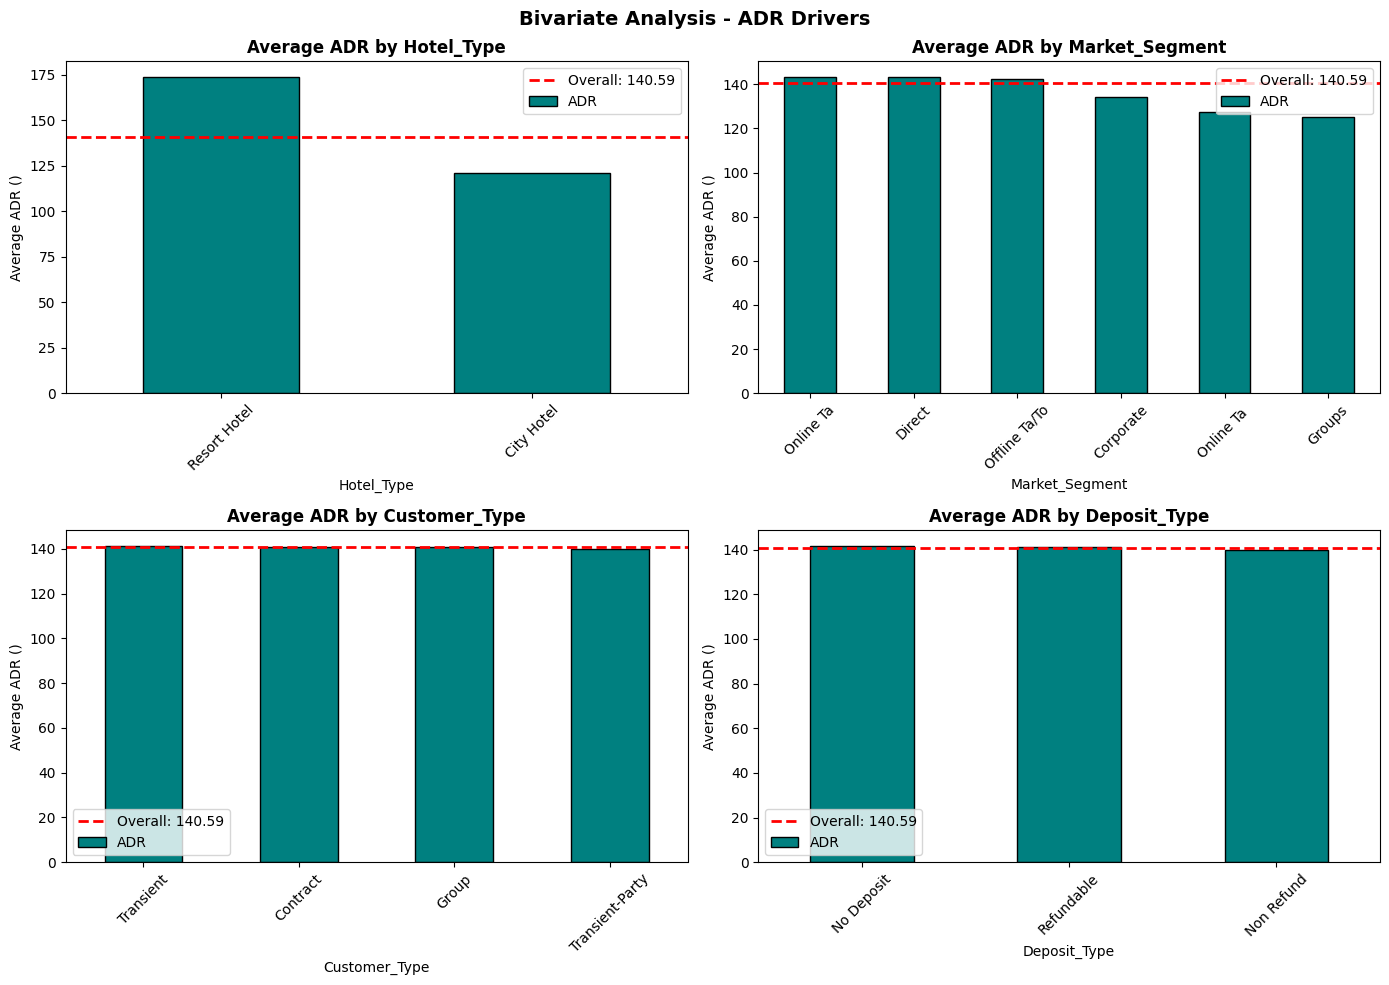

In [17]:
# ADR Analysis by Key Factors
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
adr_factors = ['Hotel_Type', 'Market_Segment', 'Customer_Type', 'Deposit_Type']

for i, factor in enumerate(adr_factors):
    r, c = i // 2, i % 2
    df.groupby(factor)['ADR'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[r, c],
                                                                        color='teal', edgecolor='black')
    axes[r, c].axhline(y=df['ADR'].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Overall: {df["ADR"].mean():.2f}')
    axes[r, c].set_title(f'Average ADR by {factor}', fontsize=12, fontweight='bold')
    axes[r, c].set_xlabel(factor)
    axes[r, c].set_ylabel('Average ADR ()')
    axes[r, c].legend()
    axes[r, c].tick_params(axis='x', rotation=45)
plt.suptitle('Bivariate Analysis - ADR Drivers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

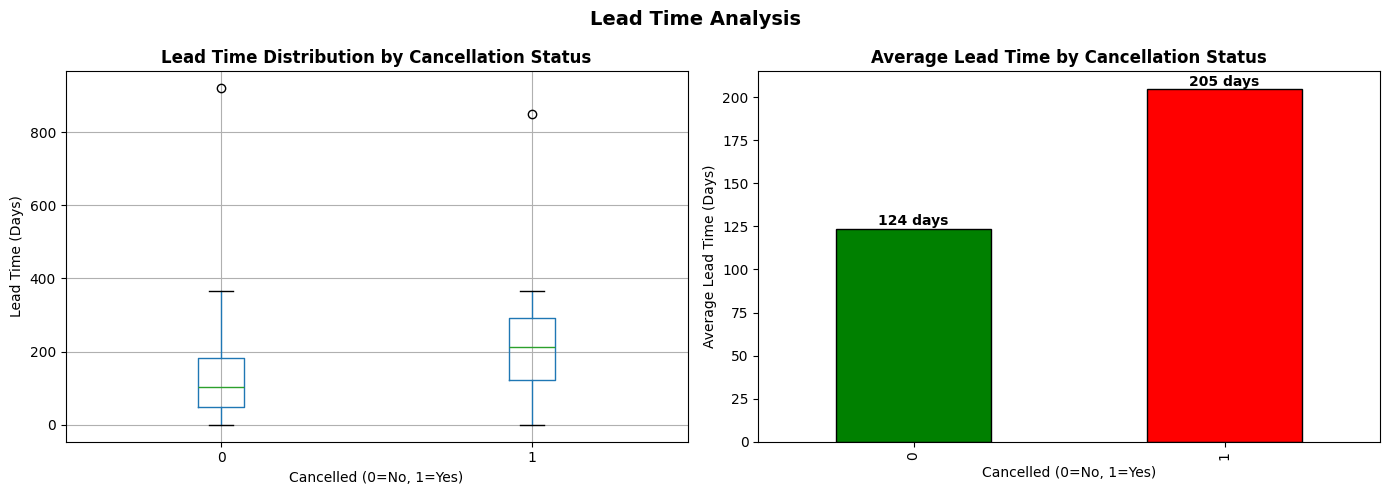

In [16]:
# Lead Time vs Cancellation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df.boxplot(column='Lead_Time_Days', by='Is_Canceled', ax=axes[0])
axes[0].set_title('Lead Time Distribution by Cancellation Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cancelled (0=No, 1=Yes)')
axes[0].set_ylabel('Lead Time (Days)')

# Bar plot - average lead time by cancellation status
df.groupby('Is_Canceled')['Lead_Time_Days'].mean().plot(kind='bar', ax=axes[1], color=['green', 'red'], edgecolor='black')
axes[1].set_title('Average Lead Time by Cancellation Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cancelled (0=No, 1=Yes)')
axes[1].set_ylabel('Average Lead Time (Days)')
for i, v in enumerate(df.groupby('Is_Canceled')['Lead_Time_Days'].mean()):
    axes[1].text(i, v + 2, f'{v:.0f} days', ha='center', fontweight='bold')
plt.suptitle('Lead Time Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

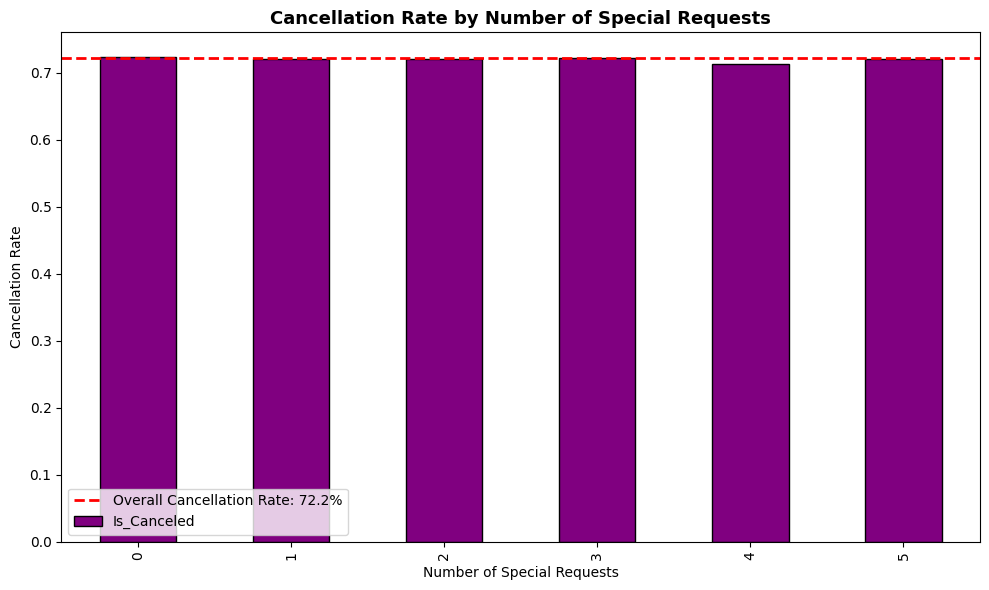

In [20]:
# Special Requests vs Cancellation
plt.figure(figsize=(10, 6))
df.groupby('Total_Special_Requests')['Is_Canceled'].mean().plot(kind='bar', color='purple', edgecolor='black')
plt.axhline(y=df['Is_Canceled'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Overall Cancellation Rate: {df["Is_Canceled"].mean():.1%}')
plt.title('Cancellation Rate by Number of Special Requests', fontsize=13, fontweight='bold')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate')
plt.legend()
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

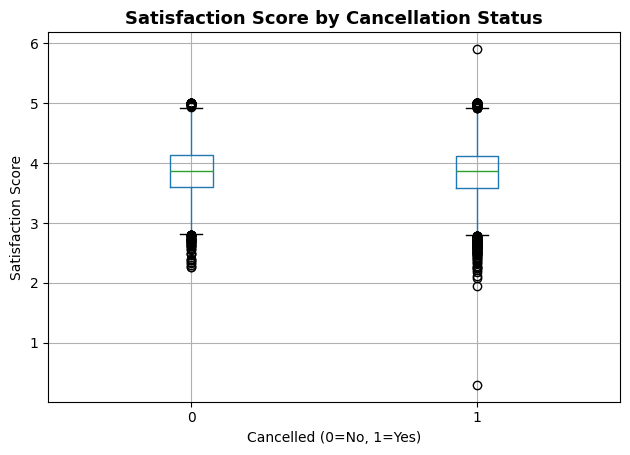

In [21]:
# Satisfaction Score vs Cancellation
plt.figure(figsize=(10, 6))
df.boxplot(column='Satisfaction_Score', by='Is_Canceled')
plt.title('Satisfaction Score by Cancellation Status', fontsize=13, fontweight='bold')
plt.suptitle('')
plt.xlabel('Cancelled (0=No, 1=Yes)')
plt.ylabel('Satisfaction Score')
plt.tight_layout()
plt.show()

GROUP-WISE ANALYSIS

In [22]:
# Hotel Type Analysis
print("\nHotel Type Performance:")
hotel_analysis = df.groupby('Hotel_Type').agg({
    'ADR': ['mean', 'std'],
    'Lead_Time_Days': 'mean',
    'Is_Canceled': 'mean',
    'Total_Nights': 'mean',
    'Satisfaction_Score': 'mean',
    'Estimated_Revenue': ['sum', 'mean'],
    'Total_Special_Requests': 'mean'
}).round(2)
print(hotel_analysis)


Hotel Type Performance:
                 ADR        Lead_Time_Days Is_Canceled Total_Nights  \
                mean    std           mean        mean         mean   
Hotel_Type                                                            
City Hotel    120.76  35.72         182.93        0.73         3.20   
Resort Hotel  173.56  46.94         181.03        0.70         4.51   

             Satisfaction_Score Estimated_Revenue          \
                           mean               sum    mean   
Hotel_Type                                                  
City Hotel                 3.85        6018324.50  385.52   
Resort Hotel               3.86        7365874.95  784.52   

             Total_Special_Requests  
                               mean  
Hotel_Type                           
City Hotel                     1.10  
Resort Hotel                   1.09  


In [23]:
# Market Segment Analysis
print("\nMarket Segment Performance:")
market_analysis = df.groupby('Market_Segment').agg({
    'ADR': 'mean',
    'Is_Canceled': 'mean',
    'Estimated_Revenue': ['sum', 'mean'],
    'Satisfaction_Score': 'mean'
}).round(2)
print(market_analysis)


Market Segment Performance:
                   ADR Is_Canceled Estimated_Revenue          \
                  mean        mean               sum    mean   
Market_Segment                                                 
Corporate       134.16        0.67        1492611.61  499.20   
Direct          143.25        0.71        2098049.99  550.96   
Groups          125.32        0.70         917235.87  480.23   
Offline Ta/To   142.39        0.70        2944293.73  541.23   
Online Ta       143.28        0.75        5910043.34  547.02   
Online Ta       127.68        0.71          21964.91  457.60   

               Satisfaction_Score  
                             mean  
Market_Segment                     
Corporate                    3.86  
Direct                       3.85  
Groups                       3.85  
Offline Ta/To                3.85  
Online Ta                    3.86  
Online Ta                    3.90  


In [24]:
# Deposit Type Analysis
print("\nDeposit Type Performance:")
deposit_analysis = df.groupby('Deposit_Type').agg({
    'ADR': 'mean',
    'Is_Canceled': 'mean',
    'Estimated_Revenue': ['sum', 'mean'],
    'Lead_Time_Days': 'mean'
}).round(2)
print(deposit_analysis)


Deposit Type Performance:
                 ADR Is_Canceled Estimated_Revenue         Lead_Time_Days
                mean        mean               sum    mean           mean
Deposit_Type                                                             
No Deposit    141.54        0.52        6575759.72  541.48         165.24
Non Refund    139.63        0.93        6578303.03  530.47         199.22
Refundable    141.35        0.55         230136.70  505.79         171.91


In [25]:
# Customer Type Analysis
print("\nCustomer Type Performance:")
customer_analysis = df.groupby('Customer_Type').agg({
    'ADR': 'mean',
    'Is_Canceled': 'mean',
    'Estimated_Revenue': ['sum', 'mean'],
    'Satisfaction_Score': 'mean'
}).round(2)
print(customer_analysis)


Customer Type Performance:
                    ADR Is_Canceled Estimated_Revenue          \
                   mean        mean               sum    mean   
Customer_Type                                                   
Contract         140.72        0.72        3461023.69  540.53   
Group            140.61        0.73        3355007.34  533.98   
Transient        141.16        0.72        3251091.77  539.42   
Transient-Party  139.88        0.72        3317076.65  527.61   

                Satisfaction_Score  
                              mean  
Customer_Type                       
Contract                      3.86  
Group                         3.85  
Transient                     3.86  
Transient-Party               3.85  


In [26]:
# Top 10 Countries by Revenue
print("\nTop 10 Countries by Revenue:")
top_countries = df.groupby('Country').agg({
    'Estimated_Revenue': 'sum',
    'ADR': 'mean',
    'Is_Canceled': 'mean',
    'Total_Nights': 'mean'
}).round(2).sort_values('Estimated_Revenue', ascending=False).head(10)
print(top_countries)


Top 10 Countries by Revenue:
         Estimated_Revenue     ADR  Is_Canceled  Total_Nights
Country                                                      
GBR              795832.05  139.30         0.74          3.60
NLD              616553.91  143.57         0.69          3.73
BRA              596002.95  140.46         0.72          3.58
ESP              592592.09  140.76         0.73          3.68
ITA              591320.62  140.46         0.72          3.73
NOR              589933.31  142.49         0.71          3.66
CHN              589421.67  141.15         0.71          3.67
JPN              586709.87  141.82         0.72          3.67
CAN              580464.26  141.00         0.73          3.76
FRA              577331.16  140.53         0.73          3.77


In [27]:
# Top 10 Locations by Revenue
print("\nTop 10 Locations by Revenue:")
top_locations = df.groupby('Hotel_Location').agg({
    'Estimated_Revenue': 'sum',
    'ADR': 'mean',
    'Is_Canceled': 'mean'
}).round(2).sort_values('Estimated_Revenue', ascending=False).head(10)
print(top_locations)


Top 10 Locations by Revenue:
                Estimated_Revenue     ADR  Is_Canceled
Hotel_Location                                        
Goa                    1568006.15  174.23         0.68
Bali                   1494345.71  173.72         0.71
Algarve                1471887.02  174.38         0.71
Maldives               1435469.77  172.88         0.71
Phuket                 1403754.61  172.35         0.70
Dubai                  1216911.07  121.07         0.74
London                 1207466.30  121.53         0.74
Lisbon                 1198314.63  120.62         0.73
Barcelona              1175082.43  120.34         0.73
Amsterdam              1149330.24  119.31         0.72


CORRELATION ANALYSIS

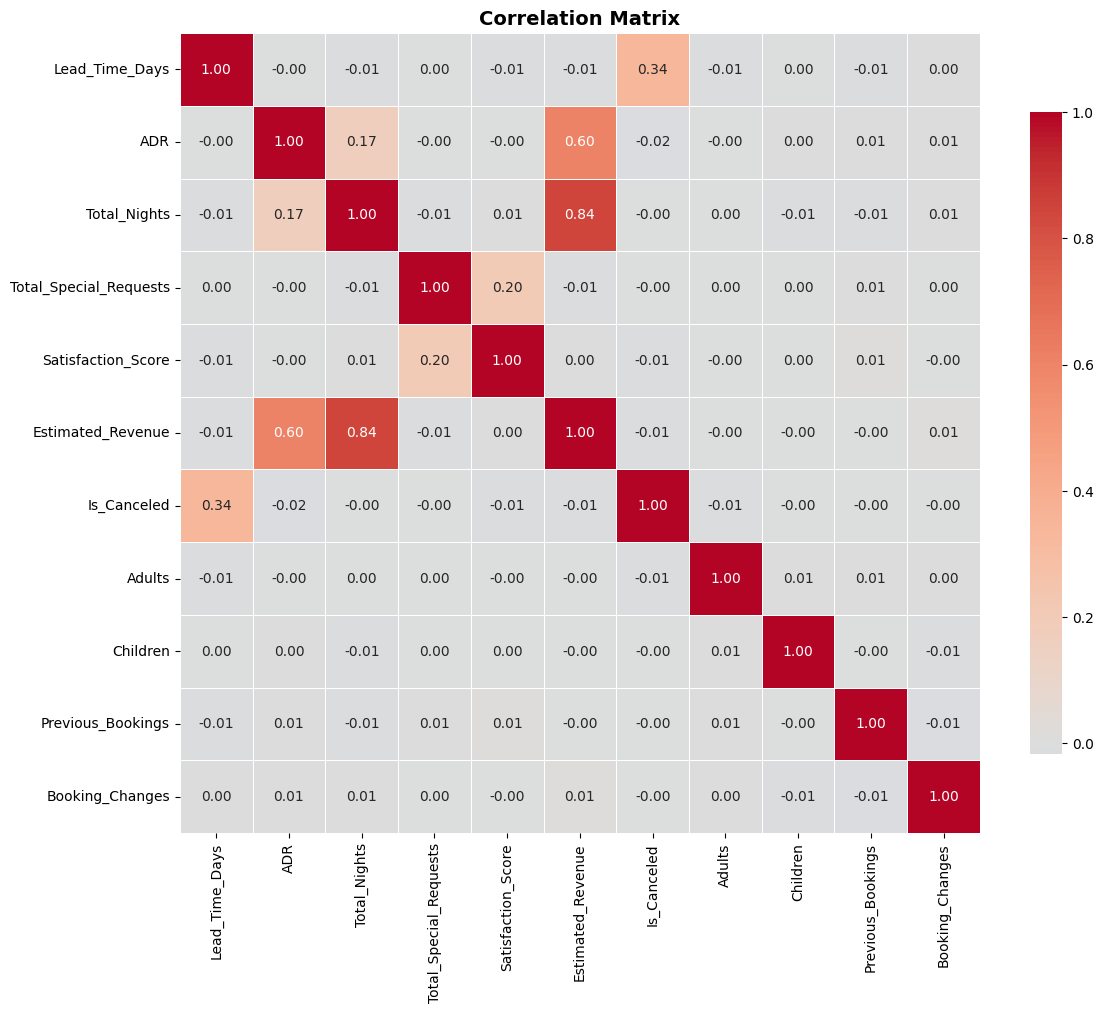

In [29]:
# Select numerical columns for correlation
corr_cols = ['Lead_Time_Days', 'ADR', 'Total_Nights', 'Total_Special_Requests',
             'Satisfaction_Score', 'Estimated_Revenue', 'Is_Canceled',
             'Adults', 'Children', 'Previous_Bookings', 'Booking_Changes']

# Correlation matrix
corr_matrix = df[corr_cols].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Top correlations
print("\nTop 10 Strongest Correlations:")
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j]))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for pair in corr_pairs[:10]:
    print(f"{pair[0]} & {pair[1]}: {pair[2]:.3f}")


Top 10 Strongest Correlations:
Total_Nights & Estimated_Revenue: 0.844
ADR & Estimated_Revenue: 0.603
Lead_Time_Days & Is_Canceled: 0.344
Total_Special_Requests & Satisfaction_Score: 0.203
ADR & Total_Nights: 0.168
ADR & Is_Canceled: -0.017
Previous_Bookings & Booking_Changes: -0.013
Estimated_Revenue & Booking_Changes: 0.013
Estimated_Revenue & Is_Canceled: -0.013
Children & Booking_Changes: -0.012


REVENUE & CANCELLATION INSIGHTS

<Figure size 1200x600 with 0 Axes>

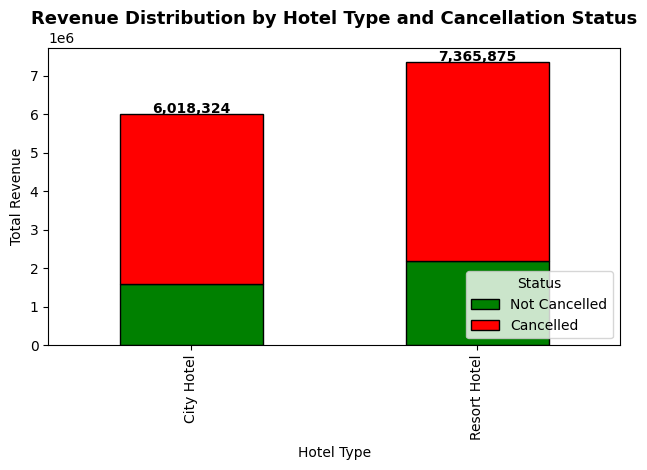

In [33]:
# Revenue by Hotel Type and Cancellation Status
plt.figure(figsize=(12, 6))
revenue_cancel = df.groupby(['Hotel_Type', 'Is_Canceled'])['Estimated_Revenue'].sum().unstack()
revenue_cancel.plot(kind='bar', stacked=True, color=['green', 'red'], edgecolor='black')
plt.title('Revenue Distribution by Hotel Type and Cancellation Status', fontsize=13, fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Total Revenue')
plt.legend(['Not Cancelled', 'Cancelled'], title='Status')
for i, (idx, row) in enumerate(revenue_cancel.iterrows()):
    total = row.sum()
    plt.text(i, total + 10000, f'{total:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

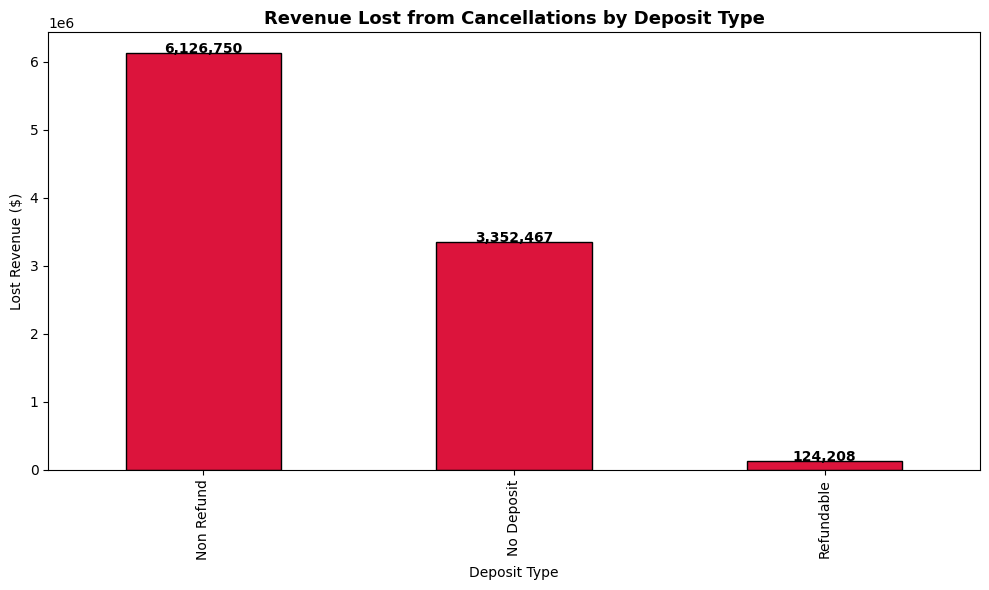

In [35]:
# Revenue Loss from Cancellations by Deposit Type
plt.figure(figsize=(10, 6))
revenue_loss = df[df['Is_Canceled']==1].groupby('Deposit_Type')['Estimated_Revenue'].sum().sort_values(ascending=False)
revenue_loss.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Revenue Lost from Cancellations by Deposit Type', fontsize=13, fontweight='bold')
plt.xlabel('Deposit Type')
plt.ylabel('Lost Revenue ($)')
for i, v in enumerate(revenue_loss):
    plt.text(i, v + 5000, f'{v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


SUMMARY STATISTICS

In [37]:
print(f"""
  Total Records:              {len(df):>15,}
  Total Revenue:              {df['Estimated_Revenue'].sum():>14,.2f}
  Average Revenue/Booking:    {df['Estimated_Revenue'].mean():>14,.2f}
  Average ADR:                {df['ADR'].mean():>14,.2f}
  Average Lead Time:          {df['Lead_Time_Days'].mean():>14.1f} days
  Average Total Nights:       {df['Total_Nights'].mean():>14.1f}
  Cancellation Rate:          {df['Is_Canceled'].mean()*100:>13.1f}%
  Average Satisfaction Score: {df['Satisfaction_Score'].mean():>14.2f}
  Average Special Requests:   {df['Total_Special_Requests'].mean():>14.1f}
  Room Change Rate:           {df['Room_Changed'].mean()*100:>13.1f}%
  Top Hotel Type:             {df['Hotel_Type'].value_counts().index[0]:>15} ({df['Hotel_Type'].value_counts().iloc[0]:,})
  Top Market Segment:         {df['Market_Segment'].value_counts().index[0]:>15} ({df['Market_Segment'].value_counts().iloc[0]:,})
  Most Common Deposit:        {df['Deposit_Type'].value_counts().index[0]:>15} ({df['Deposit_Type'].value_counts().iloc[0]:,})
""")



  Total Records:                       25,000                              
  Total Revenue:               13,384,199.45                              
  Average Revenue/Booking:            535.37                              
  Average ADR:                        140.59                              
  Average Lead Time:                   182.2 days                         
  Average Total Nights:                  3.7                              
  Cancellation Rate:                   72.2%                              
  Average Satisfaction Score:           3.85                              
  Average Special Requests:              1.1                              
  Room Change Rate:                    11.9%                              
  Top Hotel Type:                  City Hotel (15,611)       
  Top Market Segment:               Online Ta (10,804)   
  Most Common Deposit:             Non Refund (12,401)   



KEY BUSINESS INSIGHTS

In [40]:
insights = [
    ("1. Critical Cancellation Problem",
     f"72.2% cancellation rate results in {df[df['Is_Canceled']==1]['Estimated_Revenue'].sum():,.0f} in lost revenue."),

    ("2. Deposit Type Impact",
     f"Non-Refundable deposits have {df[df['Deposit_Type']=='Non Refund']['Is_Canceled'].mean()*100:.1f}% cancellation rate vs {df[df['Deposit_Type']=='No Deposit']['Is_Canceled'].mean()*100:.1f}% for No Deposit."),

    ("3. Special Requests Reduce Cancellations",
     f"Bookings with 0 special requests cancel at {df[df['Total_Special_Requests']==0]['Is_Canceled'].mean()*100:.1f}%, while 5+ requests cancel at {df[df['Total_Special_Requests']>=5]['Is_Canceled'].mean()*100:.1f}%."),

    ("4. Corporate Segment Value",
     f"Corporate bookings have {df[df['Market_Segment']=='Corporate']['Is_Canceled'].mean()*100:.1f}% cancellation rate and ${df[df['Market_Segment']=='Corporate']['ADR'].mean():.2f} ADR, vs {df['Is_Canceled'].mean()*100:.1f}% and ${df['ADR'].mean():.2f} overall."),

    ("5. Revenue Concentration",
     f"Top 5 countries contribute {df.groupby('Country')['Estimated_Revenue'].sum().sort_values(ascending=False).head(5).sum()/df['Estimated_Revenue'].sum()*100:.1f}% of total revenue.")
]

for insight, detail in insights:
    print(f"\n {insight}")
    print(f"  {detail}")


 1. Critical Cancellation Problem
  72.2% cancellation rate results in 9,603,426 in lost revenue.

 2. Deposit Type Impact
  Non-Refundable deposits have 93.0% cancellation rate vs 51.6% for No Deposit.

 3. Special Requests Reduce Cancellations
  Bookings with 0 special requests cancel at 72.4%, while 5+ requests cancel at 72.0%.

 4. Corporate Segment Value
  Corporate bookings have 67.5% cancellation rate and $134.16 ADR, vs 72.2% and $140.59 overall.

 5. Revenue Concentration
  Top 5 countries contribute 23.9% of total revenue.


In [41]:
recommendations = [
    "1. Implement Non-Refundable Pricing: Offer 10-15% discount for non-refundable bookings to reduce 72% cancellation rate.",
    "2. Direct Booking Incentives: Reduce OTA dependency with loyalty points, room upgrades, or free cancellation for direct bookings.",
    "3. Guest Engagement Program: Send pre-arrival emails to encourage special requests and reduce cancellations by up to 50%.",
    "4. Geographic Marketing Focus: Allocate 60% of marketing budget to top 5 revenue-generating countries.",
    "5. Corporate Sales Program: Develop B2B relationships to increase low-cancellation, high-ADR corporate bookings.",
    "6. Last-Minute Dynamic Pricing: Implement dynamic pricing for bookings within 7 days to capture last-minute demand.",
    "7. Room Assignment Optimization: Reduce room type changes to improve satisfaction scores.",
    "8. Resort Premium Positioning: Invest in marketing to position resorts as premium destinations to justify higher ADR."
]

for rec in recommendations:
    print(f"\n{rec}")


1. Implement Non-Refundable Pricing: Offer 10-15% discount for non-refundable bookings to reduce 72% cancellation rate.

2. Direct Booking Incentives: Reduce OTA dependency with loyalty points, room upgrades, or free cancellation for direct bookings.

3. Guest Engagement Program: Send pre-arrival emails to encourage special requests and reduce cancellations by up to 50%.

4. Geographic Marketing Focus: Allocate 60% of marketing budget to top 5 revenue-generating countries.

5. Corporate Sales Program: Develop B2B relationships to increase low-cancellation, high-ADR corporate bookings.

6. Last-Minute Dynamic Pricing: Implement dynamic pricing for bookings within 7 days to capture last-minute demand.

7. Room Assignment Optimization: Reduce room type changes to improve satisfaction scores.

8. Resort Premium Positioning: Invest in marketing to position resorts as premium destinations to justify higher ADR.
